In [1]:
''' objective - model time series containing Log Returns with Garch'''

' objective - model time series containing Log Returns with Garch'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
# pip install arch

In [4]:
from arch import arch_model

In [5]:
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [6]:
df = pd.read_csv('SPY.csv', parse_dates = True, index_col = 'Date')

In [7]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,112.370003,113.389999,111.510002,113.330002,92.246048,118944600
2010-01-05,113.260002,113.680000,112.849998,113.629997,92.490204,111579900
2010-01-06,113.519997,113.989998,113.430000,113.709999,92.555328,116074400
2010-01-07,113.500000,114.330002,113.180000,114.190002,92.946060,131091100
2010-01-08,113.889999,114.620003,113.660004,114.570000,93.255348,126402800


In [8]:
df['LogRet'] = np.log(df['Close']).diff()

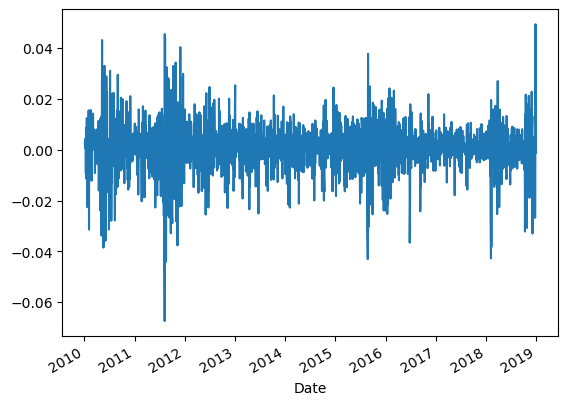

In [9]:
df['LogRet'].plot();

In [10]:
''' this is the time series we are trying to model with garch - multiple areas in the above which show volatility clustering'''

' this is the time series we are trying to model with garch - multiple areas in the above which show volatility clustering'

In [11]:
from statsmodels.tsa.stattools import adfuller

adfuller(df['LogRet'].dropna())

(np.float64(-10.46392772440614),
 np.float64(1.3368550654385274e-18),
 24,
 2237,
 {'1%': np.float64(-3.433276606916896),
  '5%': np.float64(-2.8628328925859563),
  '10%': np.float64(-2.5674582680820732)},
 np.float64(-14511.42185443443))

In [12]:
# looks pretty stationary

In [13]:
df.head(n=2)

,Open,High,Low,Close,Adj Close,Volume,LogRet
Date,,,,,,,
2010-01-04,112.370003,113.389999,111.510002,113.330002,92.246048,118944600,NaN
2010-01-05,113.260002,113.680000,112.849998,113.629997,92.490204,111579900,0.002644


In [14]:
df2 = df.iloc[1:].copy() # 1st row for log returns is nana

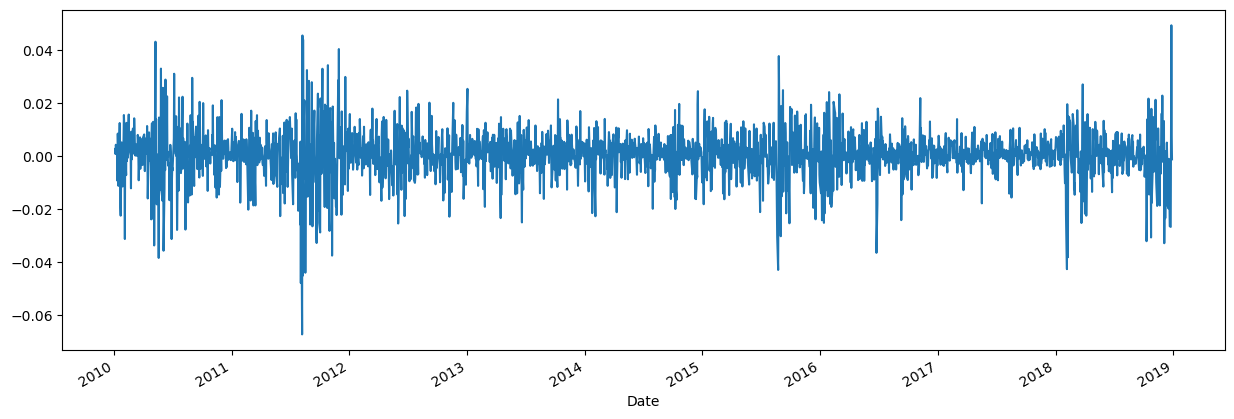

In [15]:
df2['LogRet'].plot(figsize = (15,5));

In [16]:
''' lots of volatility clustering - everytime returns have a large magnitude, its surrounded by other returns with large magnitude'''

' lots of volatility clustering - everytime returns have a large magnitude, its surrounded by other returns with large magnitude'

In [17]:
df2['Ysq'] = df['LogRet'] ** 2   # computing squares of the log returns

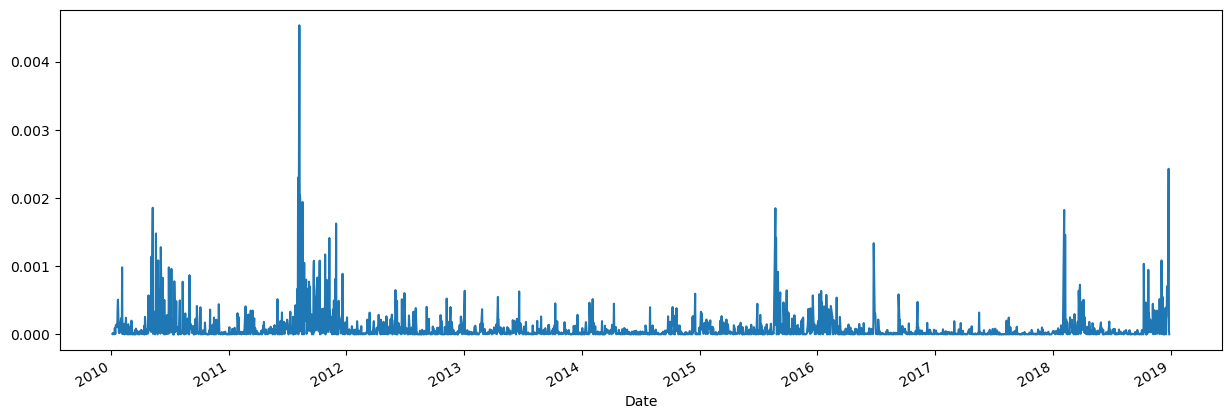

In [18]:
df2['Ysq'].plot(figsize = (15,5));

In [19]:
''' makes it easier to see that the volatility does infact cluster'''

' makes it easier to see that the volatility does infact cluster'

# ACF and PACF

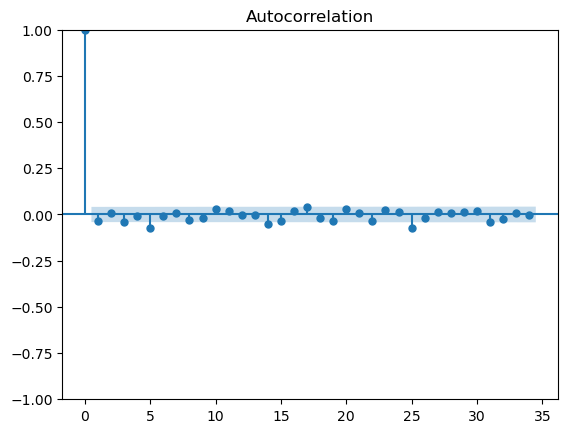

In [20]:
plot_acf(df2['LogRet']);

In [21]:
''' As expected, since log ret is just random noise, and we have seen that its just random walk - hence we see no significant lags '''

' As expected, since log ret is just random noise, and we have seen that its just random walk - hence we see no significant lags '

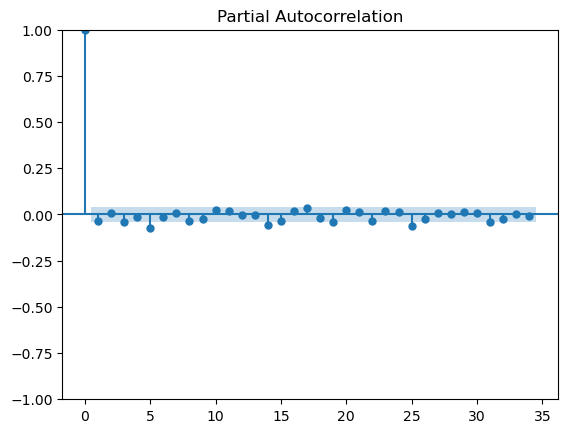

In [22]:
plot_pacf(df2['LogRet']);

In [23]:
''' same thing as pacf'''

' same thing as pacf'

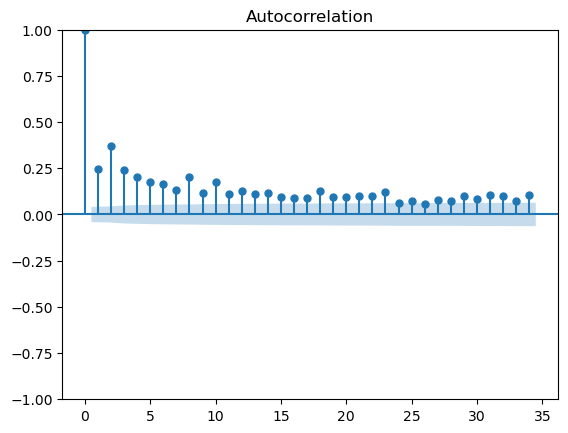

In [24]:
plot_acf(df2['Ysq']);

In [25]:
''' there is a significant correlation in the squared series, meaning the errors are not independent 
and there is relationship between errors at different times'''
'''theoritical ACF for ARCH(1) also has geometric decay for error variance'''
''' in notes, we mentioned that if we see siginificant ACF in sampled data as well, then that justifies us to use ARCH/GARCH model'''

' in notes, we mentioned that if we see siginificant ACF in sampled data as well, then that justifies us to use ARCH/GARCH model'

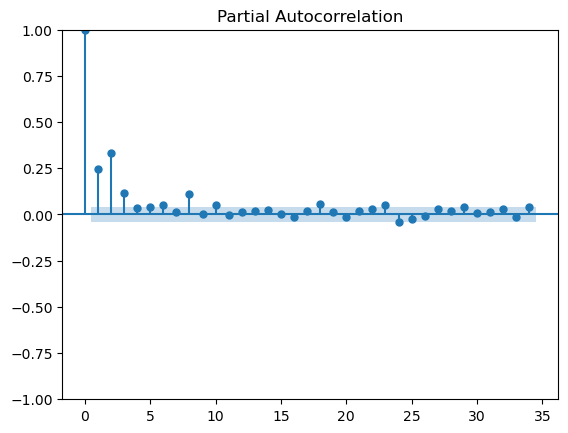

In [26]:
plot_pacf(df2['Ysq']);

In [27]:
''' very siginificant lags observed - helps us determine the p of arch(p) or garch(p,q)'''

' very siginificant lags observed - helps us determine the p of arch(p) or garch(p,q)'

In [28]:
''' checking ACF and PACF of squares of gaussian white noise
- will the ACF and PACF of squares of gaussian white noise be similar to the results we saw in stock returns?
- will this be the differentiating point between gaussian white noise and stock returns
- we know that stock returns is also like gaussian white noise'''

' checking ACF and PACF of squares of gaussian white noise\n- will the ACF and PACF of squares of gaussian white noise be similar to the results we saw in stock returns?\n- will this be the differentiating point between gaussian white noise and stock returns\n- we know that stock returns is also like gaussian white noise'

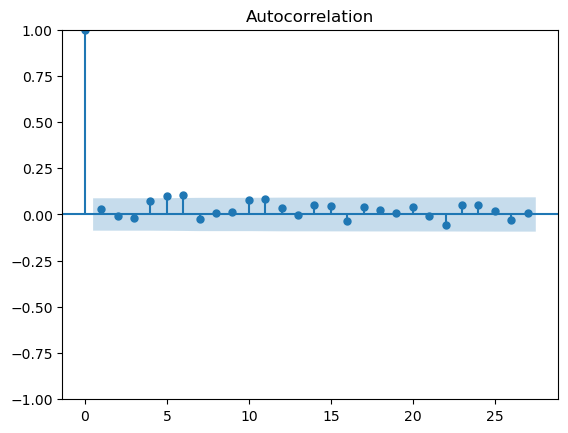

In [29]:
# checking ACF and PACF of gaussian white noise

noise_sq = np.random.randn(500)**2 # 500 points 
plot_acf(noise_sq);

In [30]:
''' no siginificant lags'''

' no siginificant lags'

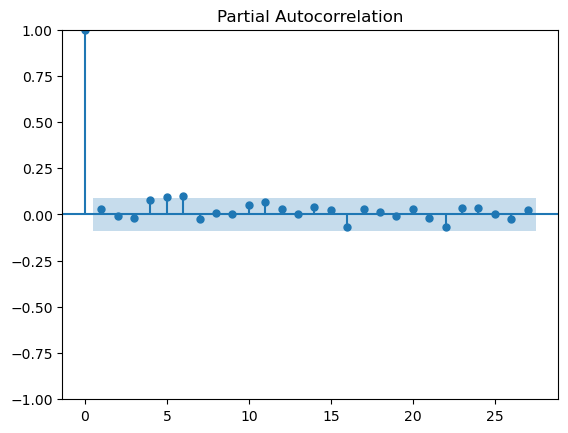

In [31]:
plot_pacf(noise_sq);

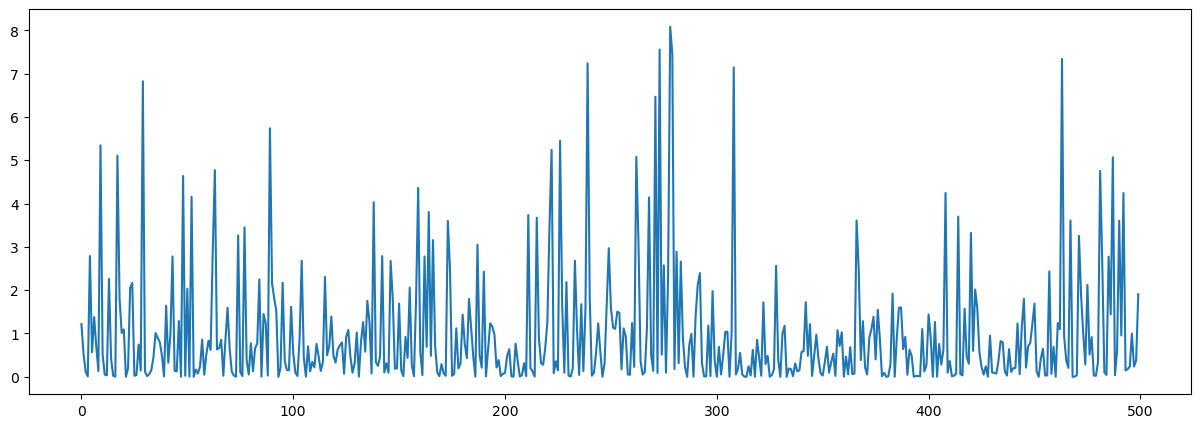

In [32]:
plt.figure(figsize = (15,5))
plt.plot(noise_sq)
plt.show();

In [33]:
''' we dont see any siginificant lags in gaussian noise since there is no phenomena of volatility clustering that we observe in stock returns'''

' we dont see any siginificant lags in gaussian noise since there is no phenomena of volatility clustering that we observe in stock returns'

# Train - Test Split

In [34]:
Ntest = 500
train  = df2.iloc[:-Ntest][['LogRet']].copy()
test  = df2.iloc[-Ntest:][['LogRet']].copy()

# why do we need scale our returns when using GARCH?

In [35]:
model = arch_model(train['LogRet'], vol = 'GARCH', p = 1 , q = 1)

# for financial time series, GARCH(1,1) is commonly used , even though the pacf of squared returns tells us that p could be larger 2 or 3
# p for GARCH tells us to take into consideration last p squared errors and q tells us to take last q variance of errors

In [36]:
''' there are lots of other parameters but not using them for now'''
''' see other parameters below'''

' see other parameters below'

In [37]:
# model = arch_model(
#                 y = training_data, # pass in the noise term we want to model ex. Log Returns 
#                 x = None,          # pass in exogenous data
#                 mean = 'Constant', # type of model we want to use for the mean portion of time series ex. zero, ARX
#                                    # time series  y(t) =  mean model  +  noise model = function(y(t-1), y(t-2),......y(t-p))  + e(t) 
#                                    # mean model = function(y(t-1), y(t-2),......y(t-p)), noise model = e(t)
#                                    # GARCH is used for the noise model, and any other model for mean model
#                                    # ARIMA is not supported by arch library for the mean model - "RUGARCH" in R supports ARIMA + GARCH, ARIMA for the mean model
#                                    # we can use ARX in arch which is like AR(p) model with the option of having exogenous inputs X - hence called ARX
#                                    # 'constant' is the default argument - this is fine since we are using stock returns which is random walk and has no autoregressive structure 
#                ### lags = 1,       # to be defined if we use mean = ARX which is essentially the p component for the ARX model 
#                vol = 'GARCH',     # vol = volatility component - represents the type of GARCH model we want to use # other options include ARCH, EGARCH etc.
#                p = 1,             # as defined in this course - p is for the ARCH part of the GARCH - for volatility component
#                q = 1,             # this is ignored id we select vol = ARCH - for volatility component
#                dist = 'Normal'      # distribution of the fit - uses Tdistribution which is a better fit for financial time series, example - StudentsT
#                                     # financial distribution has extreme peakiness in the median and gap in the shoulders
#                                     # 'Normal' is the default
#                 )

In [38]:
res = model.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 2668736234320.392
Iteration:      2,   Func. Count:     19,   Neg. LLF: 681495796603480.8
Iteration:      3,   Func. Count:     34,   Neg. LLF: 1.701275578709206e+17
Iteration:      4,   Func. Count:     49,   Neg. LLF: 2738160030335964.0
Iteration:      5,   Func. Count:     64,   Neg. LLF: 8664947886705.216
Iteration:      6,   Func. Count:     77,   Neg. LLF: 2451829078945330.0
Iteration:      7,   Func. Count:     92,   Neg. LLF: 76114823394.09409
Iteration:      8,   Func. Count:    105,   Neg. LLF: 2563086217141354.5
Iteration:      9,   Func. Count:    120,   Neg. LLF: 1650926299360767.0
Iteration:     10,   Func. Count:    134,   Neg. LLF: 2550553656242445.5
Iteration:     11,   Func. Count:    149,   Neg. LLF: 302124127038.29663
Iteration:     12,   Func. Count:    162,   Neg. LLF: 233849128707815.16
Iteration:     13,   Func. Count:    177,   Neg. LLF: 5260361271.772977
Iteration:     14,   Func. Count:    190,   Neg. LLF:

C:\Users\VARUN\anaconda3\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.532e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [39]:
''' throws a warning and suggesting to scale the data since it says its pretty small and also sugegsts the scaling''' 

' throws a warning and suggesting to scale the data since it says its pretty small and also sugegsts the scaling'

# ARCH(1)

In [40]:
# could have used the standardscaler in sklearn as well
m = train['LogRet'].mean()
s = train['LogRet'].std()
train['Scaled'] = (train['LogRet'] - m)/s
test['Scaled'] = (test['LogRet'] - m)/s
df2['Scaled'] = (df2['LogRet'] - m)/s

In [41]:
arch1 = arch_model(train['Scaled'], vol ='ARCH', p = 1)

In [42]:
res_arch1 = arch1.fit(update_freq = 2) #- update_freq parameter to tell model to print every 2 iteration - this is just for printing

Iteration:      2,   Func. Count:     13,   Neg. LLF: 3415.9317136832074
Iteration:      4,   Func. Count:     25,   Neg. LLF: 2457.9840699021793
Iteration:      6,   Func. Count:     32,   Neg. LLF: 2457.984028831145
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2457.9840288310843
            Iterations: 6
            Function evaluations: 32
            Gradient evaluations: 6


In [43]:
''' since its now scaled, we dont get warnings for scaling'''

' since its now scaled, we dont get warnings for scaling'

In [44]:
res_arch1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                 Scaled   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -2457.98
Distribution:                  Normal   AIC:                           4921.97
Method:            Maximum Likelihood   BIC:                           4938.39
                                        No. Observations:                 1762
Date:                Fri, Apr 03 2026   Df Residuals:                     1761
Time:                        13:10:02   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0127  2.325e-02      0.545      0.586 [-3.291e-02,5.825e-02]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.8188  6.722e-02     12.181  3.936e-34   [  0.687,  0.951]
alpha[1]       0.1771  4.774e-02      3.709  2.079e-04 [8.350e-02,  0.271]
==========================================================================

Covariance estimator: robust
"""

In [45]:
# Mean Model:	constant mean - this was the default parameter
# Distribution: Normal - again this is the default

In [46]:
''' notice the log likelihood for the previous unscaled model was much worse than this scaled model'''

' notice the log likelihood for the previous unscaled model was much worse than this scaled model'

In [47]:
''' see the statistics within the Mean Model section
- the coefficient is veryu small since its returns and it should be around 0
- P value of this is quite large telling that we are not very confident on the mean model (not important for us since we are interested in the volatility
part only and not the mean of the returns which we know is random walk and cant be predicted - hence p value so large
- see the confidence interval - contains both negative and positive values'''

' see the statistics within the Mean Model section\n- the coefficient is veryu small since its returns and it should be around 0\n- P value of this is quite large telling that we are not very confident on the mean model (not important for us since we are interested in the volatility\npart only and not the mean of the returns which we know is random walk and cant be predicted - hence p value so large\n- see the confidence interval - contains both negative and positive values'

In [48]:
''' 
garch(1,1) = sigma_squared(t) = (e(t)^2)/(z(t)^2) = w + alpha * e(t-1)^2 + beta * sigma_squared(t-1)
garch(1,1) = arch(1) + beta * sigma_squared(t-1)
arch(1) =  w + alpha * e(t-1)^2
'''


''' see the statistics within the Volatility Model
- the bias term W is called omega (w)
- e(t-1)^2 coefficient is called alpha 
- for both the coefficients, highly siginificant p values which means model is highly confident in the predictions (also because it can be predicted
unlike mean model which is a random walk)'''


' see the statistics within the Volatility Model\n- the bias term W is called omega (w)\n- e(t-1)^2 coefficient is called alpha \n- for both the coefficients, highly siginificant p values which means model is highly confident in the predictions (also because it can be predicted\nunlike mean model which is a random walk)'

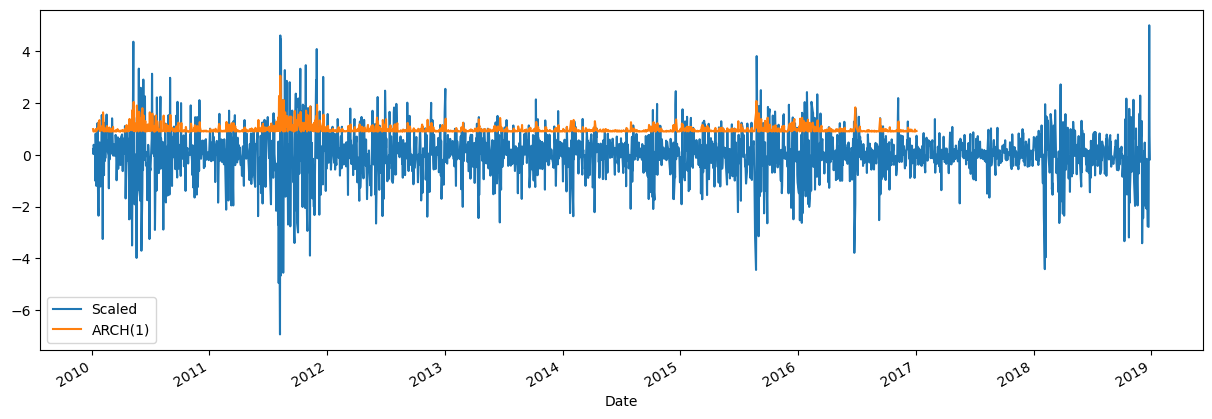

In [49]:
''' in sample predictions
- predictions are volatility which is the square root of variance'''

df2['ARCH(1)'] = res_arch1.conditional_volatility # called conditional since it is conditioned on previous squares of error terms
df2[['Scaled','ARCH(1)']].plot(figsize = (15,5));

In [50]:
''' fit seems to be just ok, underestimating when value are large and overestimatring sometimes when values are small'''
''' note that both are in the same scale although conditional volatility will always be positive'''

' note that both are in the same scale although conditional volatility will always be positive'

In [51]:
res_arch1.forecast(horizon = Ntest) # efault is reindex=True

In [52]:
fcast_arch1 = res_arch1.forecast(horizon = Ntest, reindex = True)

In [53]:
# - example
#     - reindex = True , horizon = 5 and start = 6th March, and training data is from March 1 to March 10
#             - forecast dataframe will have a row for every day from March 1 to March 10 - all the input training dates 
#                 - but only March 6 to March 10 will be filled with actual numbers for the forecast
#                 - other rows from March 1 to March 5 will be set to NaN
                
#     - reindex = False , horizon = 5 and start = 6th March, and training data is from March 1 to March 10
#             - forecast dataframe will have rows from only March 6 to March 10 and forecast for all will be filled 
            
#     - if "start" paramater is not specified, forecast will be present only for the final date of the training data
#             - if training data from March 1 to March 10, and h=5, only row with March 10 will have a forecast for dates between March 11 to march 15

In [54]:
fcast_arch1 # object of type arch model forecast

In [55]:
fcast_arch1.mean

,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.491,h.492,h.493,h.494,h.495,h.496,h.497,h.498,h.499,h.500
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
''' since we didnt specify the start parameter, it just provided forecast for the last date in training data '''
''' since we are looking at the mean, it is the mean part of the model and not related to volatility'''
''' since default mean model was constant mean, all the forecast is a constant and also it is equal to the coeff present in the model summary'''

' since default mean model was constant mean, all the forecast is a constant and also it is equal to the coeff present in the model summary'

In [57]:
fcast_arch1.variance

,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.491,h.492,h.493,h.494,h.495,h.496,h.497,h.498,h.499,h.500
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
fcast_arch1.residual_variance #if we use mean model as constant or zero, then variance and residual variance are the same

,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.491,h.492,h.493,h.494,h.495,h.496,h.497,h.498,h.499,h.500
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
''' notice that the result of variance and residual variance is exactly the same since we used mean model being constant'''

' notice that the result of variance and residual variance is exactly the same since we used mean model being constant'

In [60]:
fcast_arch1 = res_arch1.forecast(horizon =  Ntest, reindex = False)

In [61]:
fcast_arch1.mean

,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.491,h.492,h.493,h.494,h.495,h.496,h.497,h.498,h.499,h.500
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-03,0.012671,0.012671,0.012671,0.012671,0.012671,0.012671,0.012671,0.012671,0.012671,0.012671,...,0.012671,0.012671,0.012671,0.012671,0.012671,0.012671,0.012671,0.012671,0.012671,0.012671


In [62]:
''' already explained in notes why only the last date of train data appears'''

' already explained in notes why only the last date of train data appears'

In [63]:
fcast_arch1.variance

,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.491,h.492,h.493,h.494,h.495,h.496,h.497,h.498,h.499,h.500
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-03,0.912612,0.98042,0.992427,0.994553,0.994929,0.994996,0.995008,0.99501,0.99501,0.99501,...,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501


In [64]:
train.iloc[0], train.iloc[-1] # start and end dates in the train data

(LogRet    0.002644
 Scaled    0.230781
 Name: 2010-01-05 00:00:00, dtype: float64,
 LogRet    0.007621
 Scaled    0.740443
 Name: 2017-01-03 00:00:00, dtype: float64)

In [65]:
df2.head()

,Open,High,Low,Close,Adj Close,Volume,LogRet,Ysq,Scaled,ARCH(1)
Date,,,,,,,,,,
2010-01-05,113.260002,113.680000,112.849998,113.629997,92.490204,111579900,0.002644,6.988615e-06,0.230781,0.996241
2010-01-06,113.519997,113.989998,113.430000,113.709999,92.555328,116074400,0.000704,4.953455e-07,0.032152,0.909534
2010-01-07,113.500000,114.330002,113.180000,114.190002,92.946060,131091100,0.004212,1.774439e-05,0.391423,0.904929
2010-01-08,113.889999,114.620003,113.660004,114.570000,93.255348,126402800,0.003322,1.103727e-05,0.300272,0.918819
2010-01-11,115.080002,115.129997,114.239998,114.730003,93.385582,106375700,0.001396,1.947654e-06,0.102988,0.912948


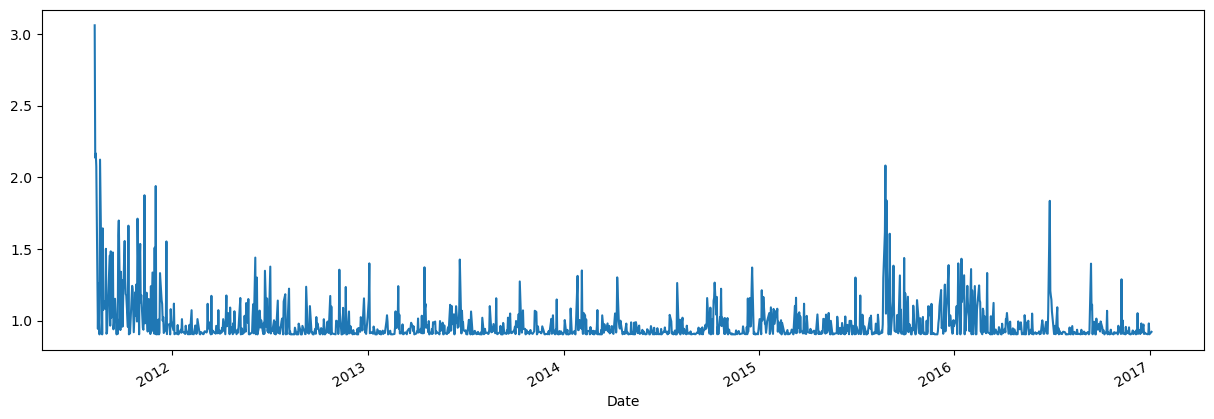

In [66]:
#plotting conditiional volatility the model has learnt
df2.loc['2011-08-09':]['ARCH(1)'].plot(figsize =(15,5));
# this date choosen since the conditional volatility on this date is too high

In [67]:
# plotting from this date to check how the forecast eveolve over time starting from this date

In [68]:
fcast_arch1 = res_arch1.forecast(horizon = Ntest, reindex = True, start = '2011-08-01')

In [69]:
fcast_arch1.variance.head()

,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.491,h.492,h.493,h.494,h.495,h.496,h.497,h.498,h.499,h.500
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
fcast_arch1.variance.loc['2011-07-28':'2011-08-05'] # these are the dates surrrounding our start date 2011-08-01

,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.491,h.492,h.493,h.494,h.495,h.496,h.497,h.498,h.499,h.500
Date,,,,,,,,,,,,,,,,,,,,,
2011-07-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,0.861165,0.971311,0.990814,0.994267,0.994879,0.994987,0.995006,0.995009,0.995010,0.995010,...,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501
2011-08-02,2.112095,1.192807,1.030033,1.001211,0.996108,0.995205,0.995045,0.995016,0.995011,0.995010,...,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501
2011-08-03,0.863233,0.971677,0.990879,0.994279,0.994881,0.994987,0.995006,0.995009,0.995010,0.995010,...,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501
2011-08-04,5.183712,1.736683,1.126334,1.018263,0.999127,0.995739,0.995139,0.995033,0.995014,0.995011,...,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501
2011-08-05,0.826340,0.965145,0.989722,0.994074,0.994844,0.994981,0.995005,0.995009,0.995010,0.995010,...,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501


In [71]:
# since reindex = True was passed, and start = 2011-08-01, no forecast before 2011-08-01 will be present even though rows for each date in 
# the training data will be present

In [72]:
fcast_arch1.variance.loc['2011-08-09'].to_numpy().shape

(500,)

In [73]:
df2.index.get_loc('2011-08-09') # row at which 2011-08-09 is present

402

In [74]:
df2.loc[:'2011-08-09']

,Open,High,Low,Close,Adj Close,Volume,LogRet,Ysq,Scaled,ARCH(1)
Date,,,,,,,,,,
2010-01-05,113.260002,113.680000,112.849998,113.629997,92.490204,111579900,0.002644,6.988615e-06,0.230781,0.996241
2010-01-06,113.519997,113.989998,113.430000,113.709999,92.555328,116074400,0.000704,4.953455e-07,0.032152,0.909534
2010-01-07,113.500000,114.330002,113.180000,114.190002,92.946060,131091100,0.004212,1.774439e-05,0.391423,0.904929
2010-01-08,113.889999,114.620003,113.660004,114.570000,93.255348,126402800,0.003322,1.103727e-05,0.300272,0.918819
2010-01-11,115.080002,115.129997,114.239998,114.730003,93.385582,106375700,0.001396,1.947654e-06,0.102988,0.912948
...,...,...,...,...,...,...,...,...,...,...
2011-08-03,125.660004,126.309998,123.529999,126.169998,105.689583,370830800,0.005404,2.920465e-05,0.513452,1.453305
2011-08-04,124.419998,124.620003,120.059998,120.260002,100.738930,520721800,-0.047974,2.301515e-03,-4.952337,0.929104
2011-08-05,121.760002,122.070000,116.860001,120.080002,100.588165,655619200,-0.001498,2.243647e-06,-0.193296,2.276777


In [75]:
df2.index[402+500]

Timestamp('2013-08-06 00:00:00')

In [76]:
df2.loc['2011-08-10':'2013-08-06', 'ARCH(1) Forecast'] = np.sqrt(fcast_arch1.variance.loc['2011-08-09'].to_numpy())

# taking sqrt since we want to measure volatility which is square root of variance and is in the same range as that of log returns
# converted it into numpy since we didnt want to use the index of the variance dataframe which would not have matched to the index of the df2 

In [77]:
fcast_arch1.variance.loc['2011-08-09'].index   
#the index highlighted below wouldnt have matched the index of the df2 which are dates - hence converted to numpy array

Index(['h.001', 'h.002', 'h.003', 'h.004', 'h.005', 'h.006', 'h.007', 'h.008',
       'h.009', 'h.010',
       ...
       'h.491', 'h.492', 'h.493', 'h.494', 'h.495', 'h.496', 'h.497', 'h.498',
       'h.499', 'h.500'],
      dtype='object', length=500)

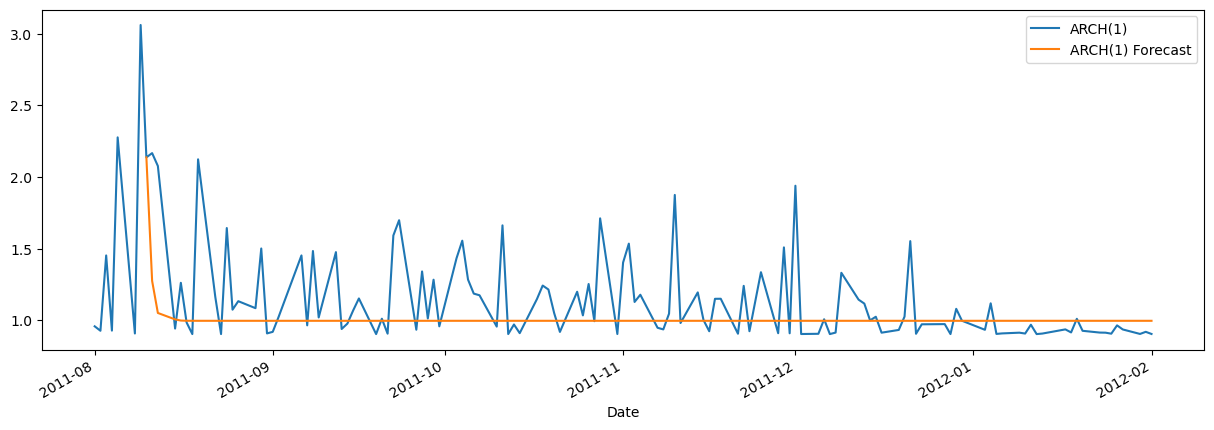

In [78]:
df2.loc['2011-08-01':'2012-02-01'] [['ARCH(1)','ARCH(1) Forecast']].plot(figsize = (15,5));

#comparing in sample predictions vs the the forecast obtained at date 2011-08-09

In [79]:
''''as already explained in the notes, garch is used for short term forecast , since volatility converges much faster'''

"'as already explained in the notes, garch is used for short term forecast , since volatility converges much faster"

In [80]:
fcast_arch1.variance.loc['2011-08-08':'2011-08-09']

,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.491,h.492,h.493,h.494,h.495,h.496,h.497,h.498,h.499,h.500
Date,,,,,,,,,,,,,,,,,,,,,
2011-08-08,9.366792,2.477360,1.257482,1.041485,1.003239,0.996467,0.995268,0.995056,0.995018,0.995012,...,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501
2011-08-09,4.567844,1.627634,1.107026,1.014844,0.998522,0.995632,0.995120,0.995030,0.995014,0.995011,...,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501,0.99501


In [81]:
''' we can see that the variance which is volatility squared is just a flat line in the later columns'''

' we can see that the variance which is volatility squared is just a flat line in the later columns'

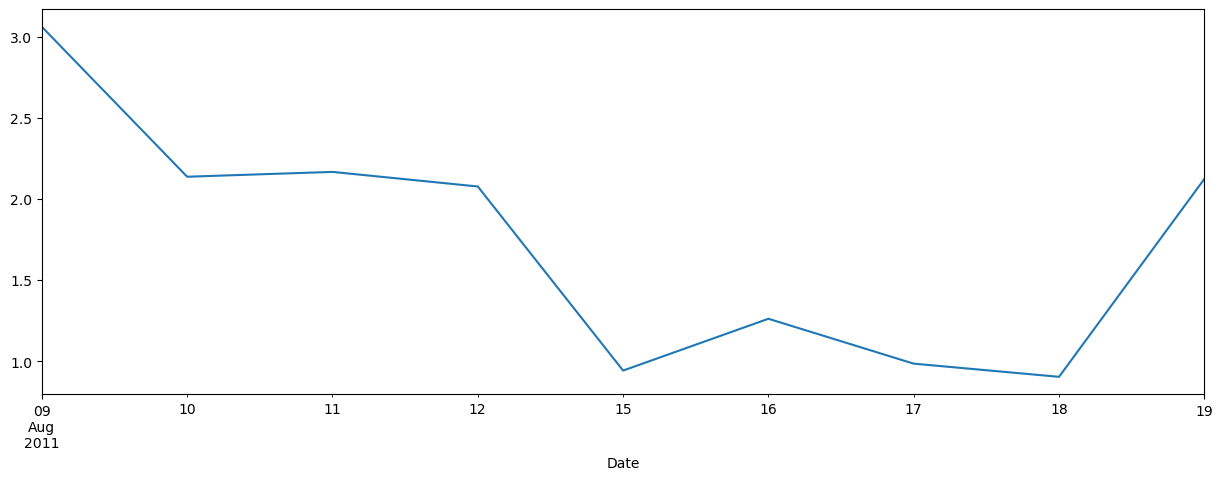

In [82]:
df2.loc['2011-08-09':'2011-08-20']['ARCH(1)'].plot(figsize =(15,5));

In [83]:
fcast_arch1.variance.index.get_loc('2011-08-17') # another special date like aug 09th Aug 2011 - this time it is lower volatility point

408

In [84]:
df2.index[408+500]

Timestamp('2013-08-14 00:00:00')

In [85]:
df2.loc['2011-08-18':'2013-08-14', 'ARCH(1) Forecast Low'] = np.sqrt(fcast_arch1.variance.loc['2011-08-17'].to_numpy())

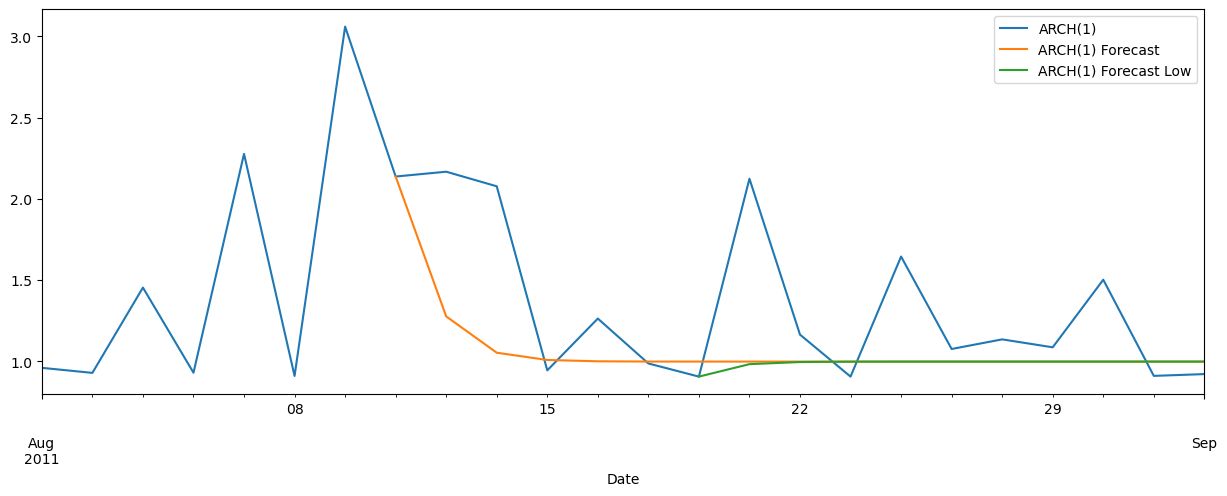

In [86]:
# comparing forecasts made from 2 dates - one date is high volatility date and the other one is low volatility date
# also putting in the ARCH(1) in sample predictions for reference

plot_cols = ['ARCH(1)','ARCH(1) Forecast','ARCH(1) Forecast Low']
df2.loc['2011-08-01':'2011-09-01'][plot_cols].plot(figsize =(15,5));


In [87]:
df2.loc['2011-08-01':'2011-09-01'][plot_cols]

,ARCH(1),ARCH(1) Forecast,ARCH(1) Forecast Low
Date,,,
2011-08-01,0.959018,NaN,NaN
2011-08-02,0.927990,NaN,NaN
2011-08-03,1.453305,NaN,NaN
2011-08-04,0.929104,NaN,NaN
2011-08-05,2.276777,NaN,NaN
2011-08-08,0.909032,NaN,NaN
2011-08-09,3.060522,NaN,NaN
2011-08-10,2.137251,2.137251,NaN
2011-08-11,2.166960,1.275788,NaN


In [88]:
''' the 1st value of arch(1) forecast for both high and low volatility points is same as insample prediction'''
''' also notice that the forecasted volatility converges to the same value for both forecasts'''
''' this is because at later lags it becomes unconditional volatility (which is a fixed value omega/(1- alpha)'''

' this is because at later lags it becomes unconditional volatility (which is a fixed value omega/(1- alpha)'

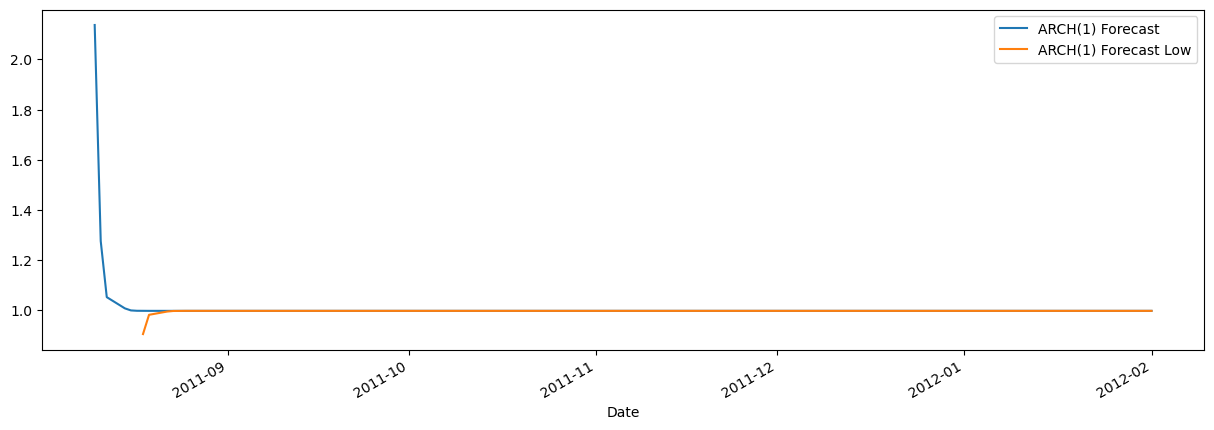

In [89]:
plot_cols = ['ARCH(1) Forecast','ARCH(1) Forecast Low']
df2.loc['2011-08-01':'2012-02-01'][plot_cols].plot(figsize =(15,5));

In [90]:
'''notice that no matter what the starting point is both values end up converging to the same value'''
''' this is because at later lags it becomes unconditional volatility (which is a fixed value omega/(1- alpha)'''

' this is because at later lags it becomes unconditional volatility (which is a fixed value omega/(1- alpha)'

In [91]:
# theoritical unconditional variance
res_arch1.params

mu          0.012671
omega       0.818829
alpha[1]    0.177065
Name: params, dtype: float64

In [92]:
res_arch1.params['omega'] / (1 - res_arch1.params['alpha[1]'])

np.float64(0.9950100810516654)

In [93]:
''' the above value is same as what it converges to for both the forecasts'''

' the above value is same as what it converges to for both the forecasts'

In [94]:
fcast_arch1.variance.loc['2011-08-09'].to_numpy()[-1]

np.float64(0.9950100810516654)

In [95]:
fcast_arch1.variance.loc['2011-08-17'].to_numpy()[-1]

np.float64(0.9950100810516654)

# GARCH(1,1) - most popular garch since it fits the financial time series quite well
### also since its 1,1, its parsimonious model

In [96]:
garch11 =  arch_model(train['Scaled'], vol = 'GARCH', p = 1, q = 1)

In [97]:
''' last 3 arguments not necessary, they are the default values'''

' last 3 arguments not necessary, they are the default values'

In [98]:
res_garch11 = garch11.fit(update_freq =2)

Iteration:      2,   Func. Count:     15,   Neg. LLF: 40132559409.52662
Iteration:      4,   Func. Count:     30,   Neg. LLF: 3107.378674913882
Iteration:      6,   Func. Count:     42,   Neg. LLF: 2269.318490494837
Iteration:      8,   Func. Count:     52,   Neg. LLF: 2269.109008505501
Iteration:     10,   Func. Count:     62,   Neg. LLF: 2269.107952003156
Iteration:     12,   Func. Count:     71,   Neg. LLF: 2269.1079418271074
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2269.107941826056
            Iterations: 12
            Function evaluations: 71
            Gradient evaluations: 12


In [99]:
res_garch11.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                 Scaled   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2269.11
Distribution:                  Normal   AIC:                           4546.22
Method:            Maximum Likelihood   BIC:                           4568.11
                                        No. Observations:                 1762
Date:                Fri, Apr 03 2026   Df Residuals:                     1761
Time:                        13:10:11   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0287  1.865e-02      1.538      0.124 [-7.863e-03,6.525e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0469  1.060e-02      4.427  9.560e-06 [2.615e-02,6.770e-02]
alpha[1]       0.1499  2.499e-02      6.000  1.972e-09     [  0.101,  0.199]
beta[1]        0.8021  2.545e-02     31.516 5.231e-218     [  0.752,  0.852]
============================================================================

Covariance estimator: robust
"""

In [100]:
''' the log likelihood and the aic much better than arch1'''

' the log likelihood and the aic much better than arch1'

In [101]:
# res_arch1.summary()

In [102]:
'''beta1 coefficient appears now which was not there in arch(1) - this is coefficient against the previous variance at t-1
-beta 1 very small p value indicating its very significant which makes sense given the improvement in the likelihood and the aic'''

'beta1 coefficient appears now which was not there in arch(1) - this is coefficient against the previous variance at t-1\n-beta 1 very small p value indicating its very significant which makes sense given the improvement in the likelihood and the aic'

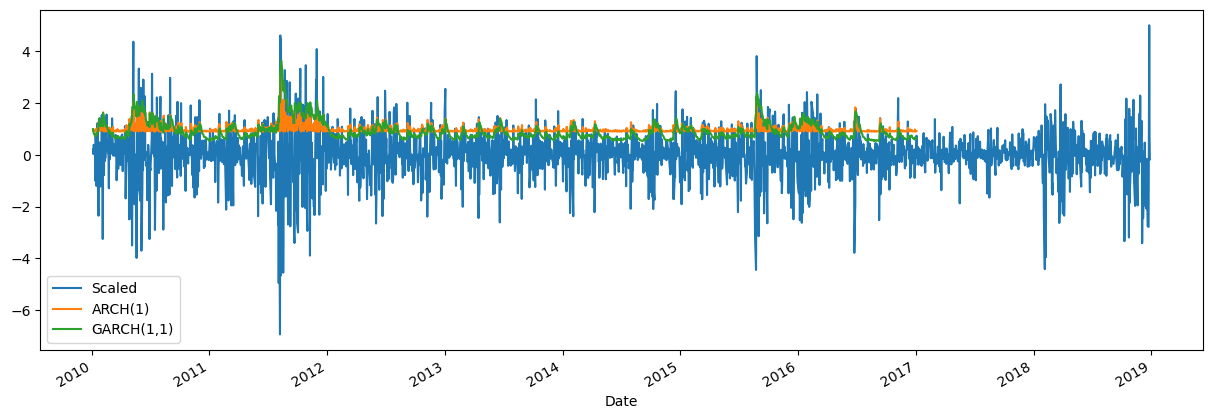

In [103]:
df2['GARCH(1,1)'] = res_garch11.conditional_volatility
df2[['Scaled','ARCH(1)','GARCH(1,1)']].plot(figsize =(15,5));

In [104]:
df2.shape

(2262, 13)

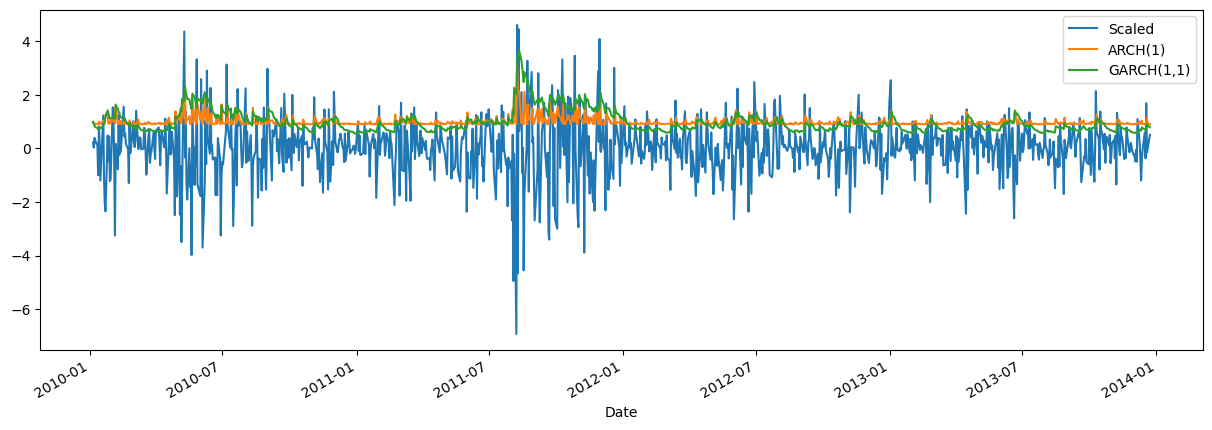

In [105]:
df2.iloc[:1000][['Scaled','ARCH(1)','GARCH(1,1)']].plot(figsize =(15,5));

In [106]:
''' Garch(1,1) much better fit - able to match both higher and lower values'''

' Garch(1,1) much better fit - able to match both higher and lower values'

In [107]:
fcast_garch11 = res_garch11.forecast(horizon = Ntest, reindex = False, start = '2011-08-09')

In [108]:
df2.loc['2011-08-10':'2013-08-06','GARCH(1,1) Forecast'] = np.sqrt(fcast_garch11.residual_variance.loc['2011-08-09'].to_numpy())

In [109]:
df2['AbsScaled'] = df2['Scaled'].abs() 

In [110]:
''' doing the above since forecast of volatility is always positive. Should have done it earlier during ARCH(1)'''

' doing the above since forecast of volatility is always positive. Should have done it earlier during ARCH(1)'

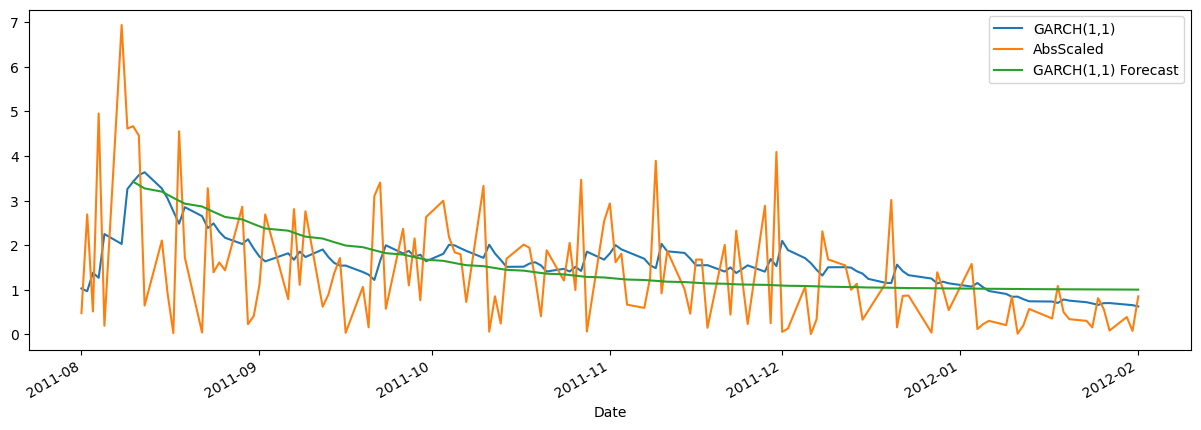

In [111]:
# plot_cols = ['ARCH(1)','GARCH(1,1)','AbsScaled','ARCH(1) Forecast','GARCH(1,1) Forecast']
plot_cols = ['GARCH(1,1)','AbsScaled','GARCH(1,1) Forecast']
df2.loc['2011-08-01':'2012-02-01'][plot_cols].plot(figsize  = (15,5));

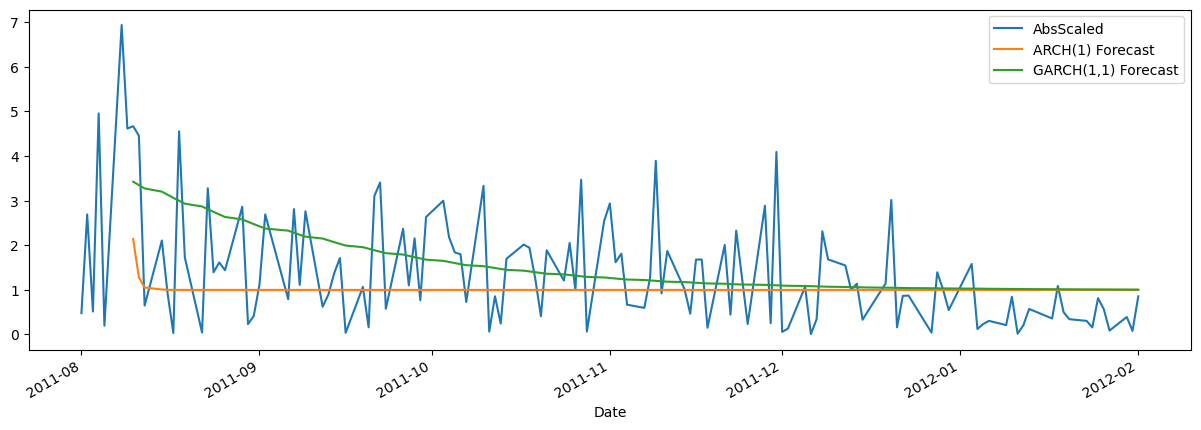

In [112]:
plot_cols = ['AbsScaled','ARCH(1) Forecast','GARCH(1,1) Forecast']
# plot_cols = ['GARCH(1,1)','AbsScaled','GARCH(1,1) Forecast']
df2.loc['2011-08-01':'2012-02-01'][plot_cols].plot(figsize  = (15,5));

In [113]:
'''Garch model matches the actual data much more closely'''

''' arch 1 converges much faster'''

''' IMPORTANT - meaning GARCH model much more persistent
 
 - it happens such way because ARCH(1) only dependent on the previous error at lag 1. so if there was something very off at lag 2 or before, arch(1) 
 will not be able to predicr this
 
 - GARCH(1,1) model depends not just on the prev error at lag 1 (which is essentially arch1), but also variance at lag 1
         - since variance of lag 1 again depends on lag 2 (since variance depends on previous lags), the effect of the previous lags propogates
         - essentially, GARCH(1,1) is ARCH(infinity) making it much more persistent'''

' IMPORTANT - meaning GARCH model much more persistent\n \n - it happens such way because ARCH(1) only dependent on the previous error at lag 1. so if there was something very off at lag 2 or before, arch(1) \n will not be able to predicr this\n \n - GARCH(1,1) model depends not just on the prev error at lag 1 (which is essentially arch1), but also variance at lag 1\n         - since variance of lag 1 again depends on lag 2 (since variance depends on previous lags), the effect of the previous lags propogates\n         - essentially, GARCH(1,1) is ARCH(infinity) making it much more persistent'

In [114]:
''' note that previously, we were comparing forecast with insample predictions , now we are comparing actuals with forecast'''

' note that previously, we were comparing forecast with insample predictions , now we are comparing actuals with forecast'

# t-distribution
#### by default, the distribution is set to Normal, but financial time series has mostly t distribution meaning, at the median its much more peaky
#### and in the shoulder there is a gap comnpared to Normal/Gaussian 

In [115]:
garch11t = arch_model(train['Scaled'], vol ='GARCH', p =1, q=1 , dist = 'StudentsT')

In [116]:
res_garch11t = garch11t.fit(update_freq=2)

Iteration:      2,   Func. Count:     17,   Neg. LLF: 57266.67059870567
Iteration:      4,   Func. Count:     34,   Neg. LLF: 4427.5507542217265
Iteration:      6,   Func. Count:     48,   Neg. LLF: 2232.8419831316087
Iteration:      8,   Func. Count:     62,   Neg. LLF: 2230.2092215498465
Iteration:     10,   Func. Count:     74,   Neg. LLF: 2230.182985386682
Iteration:     12,   Func. Count:     86,   Neg. LLF: 2230.17978874367
Iteration:     14,   Func. Count:     97,   Neg. LLF: 2230.1797865895405
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2230.1797865895423
            Iterations: 14
            Function evaluations: 97
            Gradient evaluations: 14


In [117]:
res_garch11t.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - GARCH Model Results                         
====================================================================================
Dep. Variable:                       Scaled   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2230.18
Distribution:      Standardized Student's t   AIC:                           4470.36
Method:                  Maximum Likelihood   BIC:                           4497.73
                                              No. Observations:                 1762
Date:                      Fri, Apr 03 2026   Df Residuals:                     1761
Time:                              13:10:20   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0471  1.691e-02      2.788  5.309e-03 [1.400e-02,8.028e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0399  9.295e-03      4.296  1.742e-05 [2.171e-02,5.815e-02]
alpha[1]       0.1615  2.507e-02      6.442  1.180e-10     [  0.112,  0.211]
beta[1]        0.8081  2.353e-02     34.350 1.427e-258     [  0.762,  0.854]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.5803      0.733      7.610  2.736e-14 [  4.143,  7.017]
========================================================================

Covariance estimator: robust
"""

In [118]:
''' better log likelihood and aic than garch with normal distribution'''
''' also in t distirbutin has degrees of freedom thing which also has significant p value'''

' also in t distirbutin has degrees of freedom thing which also has significant p value'

In [119]:
# res_garch11.summary()

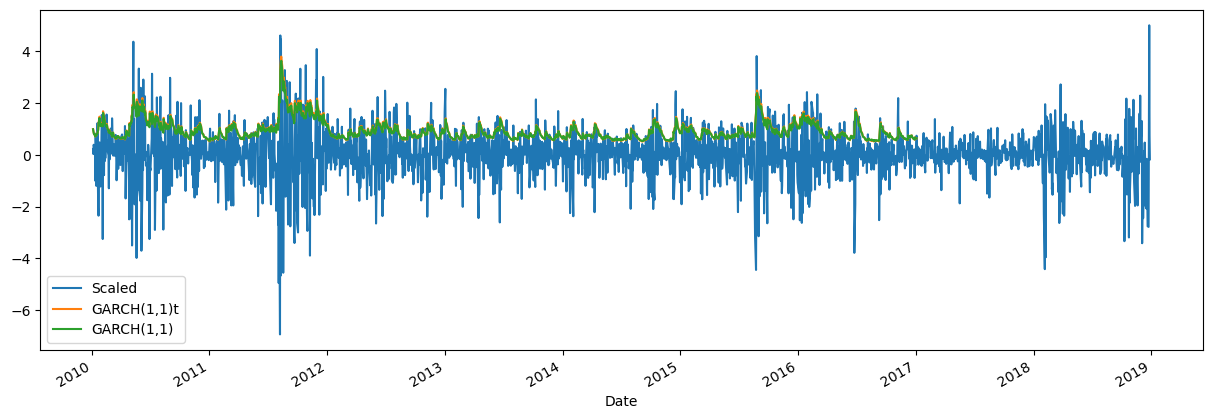

In [120]:
df2['GARCH(1,1)t'] = res_garch11t.conditional_volatility
df2[['Scaled','GARCH(1,1)t','GARCH(1,1)']].plot(figsize =(15,5));


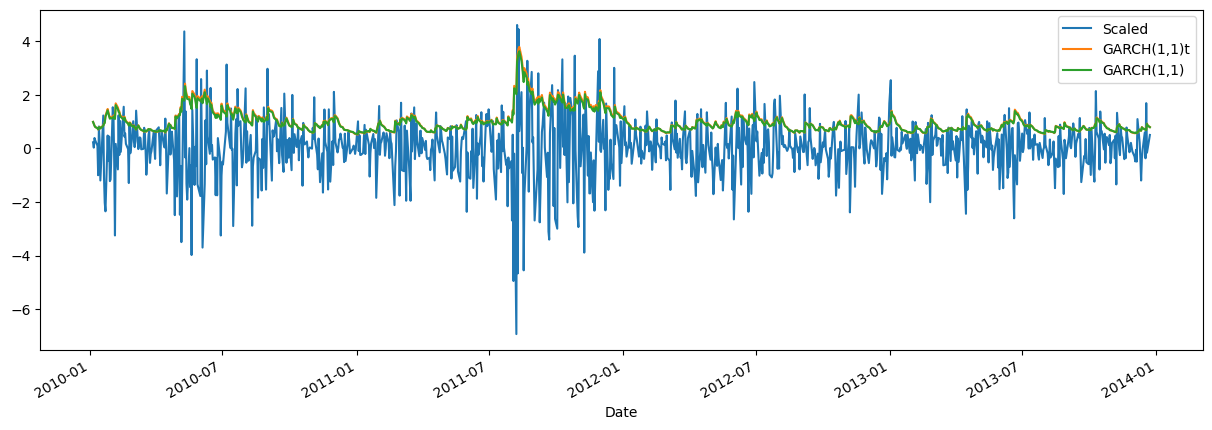

In [121]:
df2.iloc[:1000][['Scaled','GARCH(1,1)t','GARCH(1,1)']].plot(figsize =(15,5));

In [122]:
'''results look essentially the same '''

'results look essentially the same '

In [123]:
fcast_garch11t = res_garch11t.forecast(horizon = Ntest, reindex = False, start = '2011-08-09')

In [124]:
df2.loc['2011-08-10':'2013-08-06','GARCH(1,1)t Forecast'] = np.sqrt(fcast_garch11t.residual_variance.loc['2011-08-09'].to_numpy())


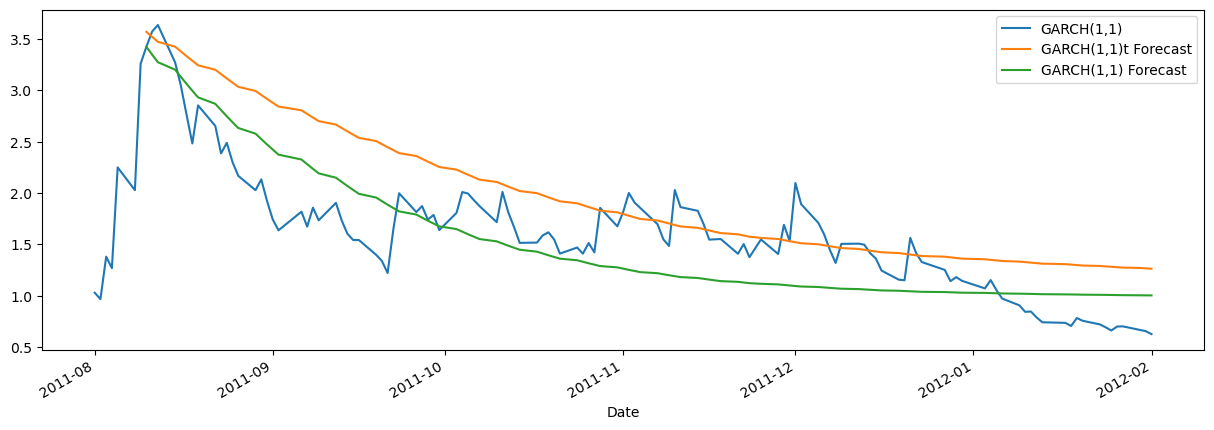

In [125]:
# plot_cols = ['ARCH(1)','GARCH(1,1)','AbsScaled','ARCH(1) Forecast','GARCH(1,1) Forecast']
plot_cols = ['GARCH(1,1)','GARCH(1,1)t Forecast','GARCH(1,1) Forecast']
df2.loc['2011-08-01':'2012-02-01'][plot_cols].plot(figsize  = (15,5));


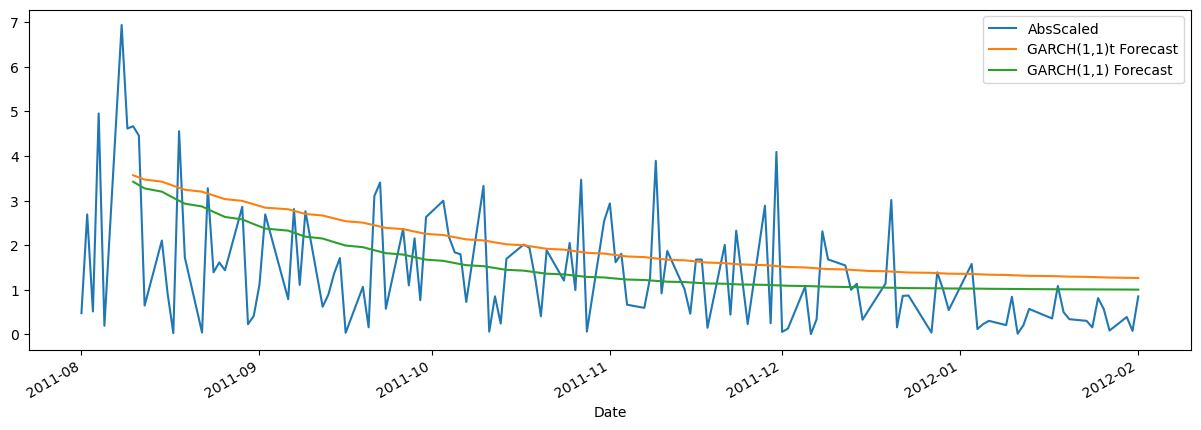

In [126]:
plot_cols = ['AbsScaled','GARCH(1,1)t Forecast','GARCH(1,1) Forecast']
# plot_cols = ['GARCH(1,1)','AbsScaled','GARCH(1,1) Forecast']
df2.loc['2011-08-01':'2012-02-01'][plot_cols].plot(figsize  = (15,5));

In [127]:
'''more persistence shown in the t distribution compared to the garch(1,1) normal'''

'more persistence shown in the t distribution compared to the garch(1,1) normal'

# GARCH(p,q)

In [128]:
garchpq = arch_model(train['Scaled'], vol ='GARCH', p =8, q=5 , dist = 'StudentsT') 
# couild have looked at the pacf we plotted earlier to take a better estimate, p was 3 there , but just trying some value

In [129]:
res_garchpq = garchpq.fit(update_freq=2)

Iteration:      2,   Func. Count:     39,   Neg. LLF: 4293.3519981065465
Iteration:      4,   Func. Count:     75,   Neg. LLF: 7737.054238153957
Iteration:      6,   Func. Count:    111,   Neg. LLF: 2990.3116317803815
Iteration:      8,   Func. Count:    148,   Neg. LLF: 2441.3391715998705
Iteration:     10,   Func. Count:    186,   Neg. LLF: 2611.9082799026037
Iteration:     12,   Func. Count:    223,   Neg. LLF: 3924.931045509482
Iteration:     14,   Func. Count:    260,   Neg. LLF: 2250.431175102145
Iteration:     16,   Func. Count:    297,   Neg. LLF: 2250.951965758821
Iteration:     18,   Func. Count:    333,   Neg. LLF: 2225.103560441064
Iteration:     20,   Func. Count:    369,   Neg. LLF: 2224.5165967237463
Iteration:     22,   Func. Count:    403,   Neg. LLF: 2224.3050395293576
Iteration:     24,   Func. Count:    437,   Neg. LLF: 2224.2242041339982
Iteration:     26,   Func. Count:    471,   Neg. LLF: 2224.218156869057
Iteration:     28,   Func. Count:    505,   Neg. LLF: 222

In [130]:
res_garchpq.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - GARCH Model Results                         
====================================================================================
Dep. Variable:                       Scaled   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2224.22
Distribution:      Standardized Student's t   AIC:                           4480.44
Method:                  Maximum Likelihood   BIC:                           4568.02
                                              No. Observations:                 1762
Date:                      Fri, Apr 03 2026   Df Residuals:                     1761
Time:                              13:10:30   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0483  1.715e-02      2.817  4.846e-03 [1.470e-02,8.192e-02]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1008  5.516e-02      1.827  6.774e-02 [-7.349e-03,  0.209]
alpha[1]       0.0744  3.351e-02      2.220  2.643e-02  [8.710e-03,  0.140]
alpha[2]       0.1687  6.307e-02      2.675  7.474e-03  [4.509e-02,  0.292]
alpha[3]   1.9502e-14      0.108  1.801e-13      1.000    [ -0.212,  0.212]
alpha[4]       0.0116  9.808e-02      0.118      0.906    [ -0.181,  0.204]
alpha[5]       0.0370  7.045e-02      0.525      0.599    [ -0.101,  0.175]
alpha[6]       0.0277  5.508e-02      0.503      0.615 [-8.027e-02,  0.136]
alpha[7]       0.0145  6.711e-02      0.216      0.829    [ -0.117,  0.146]
alpha[8]       0.0381  5.693e-02      0.670      0.503 [-7.343e-02,  0.150]
beta[1]        0.5490      0.499      1.100      0.271    [ -0.429,  1.527]
beta[2]    5.7383e-15      0.622  9.219e-15      1.000    [ -1.220,  1.220]
beta[3]        0.0000      0.549      0.000      1.000    [ -1.076,  1.076]
beta[4]    7.9703e-15      0.354  2.253e-14      1.000    [ -0.693,  0.693]
beta[5]    3.0220e-14      0.346  8.727e-14      1.000    [ -0.679,  0.679]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.7008      0.772      7.386  1.511e-13 [  4.188,  7.214]
========================================================================

Covariance estimator: robust
"""

In [131]:
''' slightly better log likelihood with slightly worse aic than garch 11'''
'''if we look at lags greater than 2, they do not have significant p values , even beta doesnt have significant p values'''

'if we look at lags greater than 2, they do not have significant p values , even beta doesnt have significant p values'

In [132]:
# res_garch11t.summary()

In [133]:
res_arch1.aic, res_garch11.aic, res_garch11t.aic, res_garchpq.aic

(4921.968057662169, 4546.215883652112, 4470.359573179085, 4480.436233913599)

In [134]:
''' aic worse for arch1, best for garch 11 r'''
''' rejecting garch 85 since its giving worse aic and not even parsimonious'''

' rejecting garch 85 since its giving worse aic and not even parsimonious'

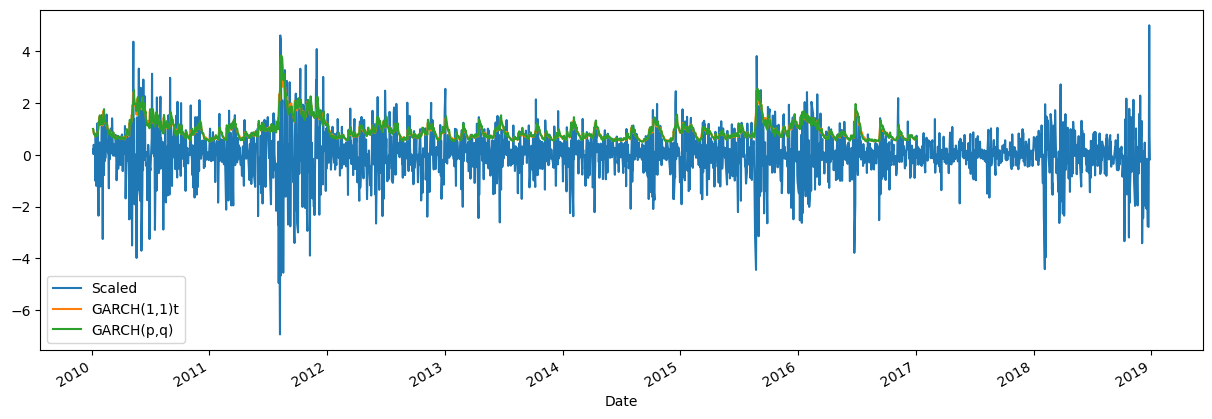

In [135]:
df2['GARCH(p,q)'] = res_garchpq.conditional_volatility
df2[['Scaled','GARCH(1,1)t','GARCH(p,q)']].plot(figsize =(15,5));


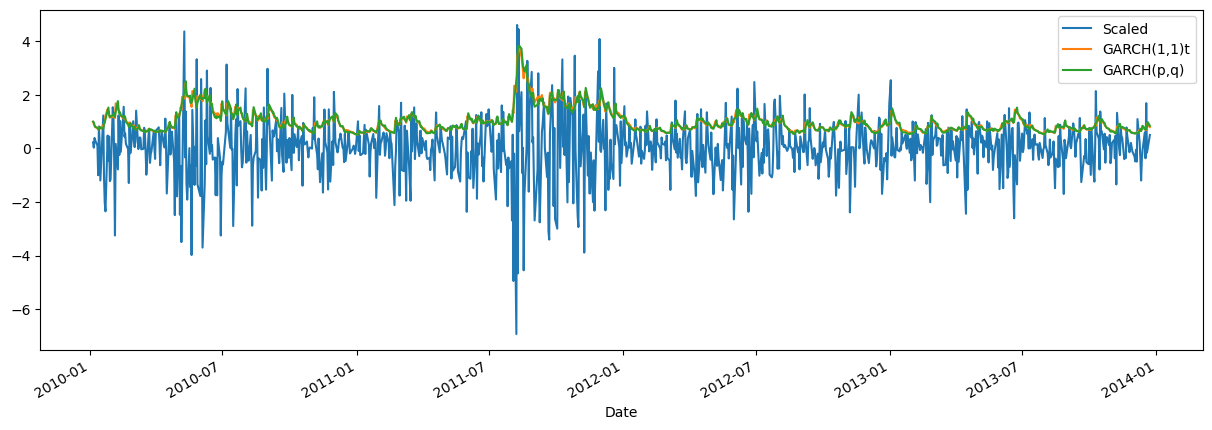

In [136]:
df2.iloc[:1000][['Scaled','GARCH(1,1)t','GARCH(p,q)']].plot(figsize =(15,5));

In [137]:
''' no siginificant difference observed'''

' no siginificant difference observed'

In [138]:
fcast_garchpq = res_garchpq.forecast(horizon = Ntest, reindex = False, start = '2011-08-09')

In [139]:
df2.loc['2011-08-10':'2013-08-06','GARCH(p,q) Forecast'] = np.sqrt(fcast_garchpq.residual_variance.loc['2011-08-09'].to_numpy())


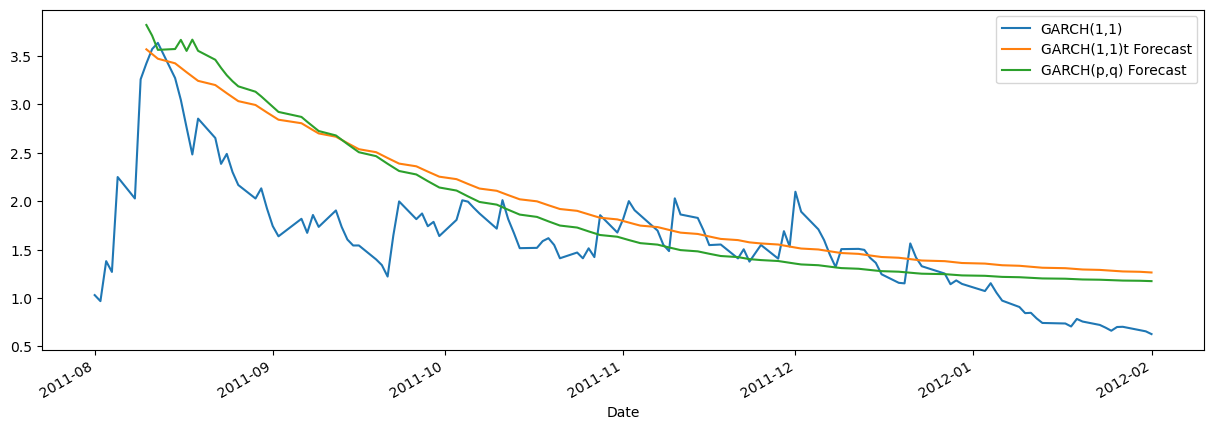

In [140]:
# plot_cols = ['ARCH(1)','GARCH(1,1)','AbsScaled','ARCH(1) Forecast','GARCH(1,1) Forecast']
plot_cols = ['GARCH(1,1)','GARCH(1,1)t Forecast','GARCH(p,q) Forecast']
df2.loc['2011-08-01':'2012-02-01'][plot_cols].plot(figsize  = (15,5));


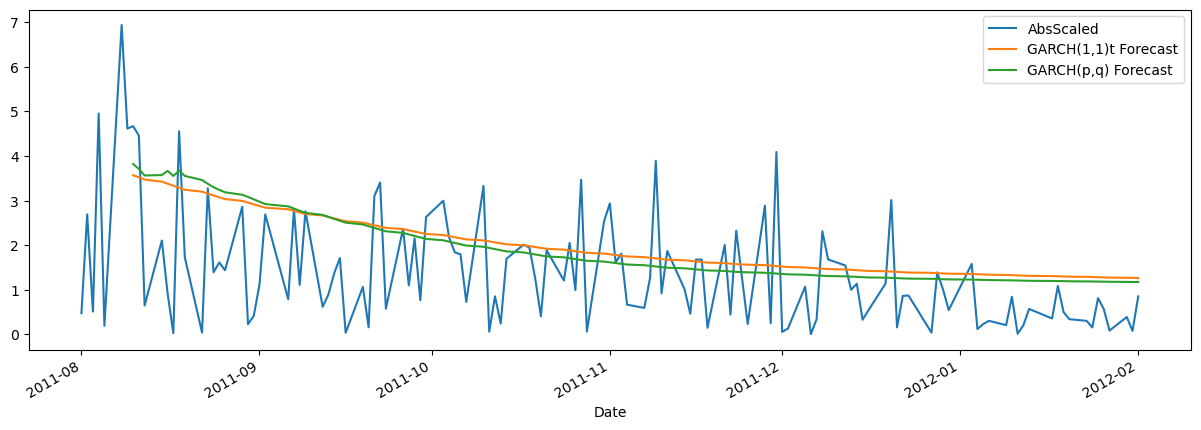

In [141]:
plot_cols = ['AbsScaled','GARCH(1,1)t Forecast','GARCH(p,q) Forecast']
# plot_cols = ['GARCH(1,1)','AbsScaled','GARCH(1,1) Forecast']
df2.loc['2011-08-01':'2012-02-01'][plot_cols].plot(figsize  = (15,5));

In [142]:
''' no advantage to using garch p,q'''

' no advantage to using garch p,q'

# forecasting for test set

In [144]:
train_idx = df2.index <= train.index[-1]
test_idx = ~train_idx

In [145]:
df2.loc[train_idx,'GARCH(p,q) Train'] = res_garchpq.conditional_volatility
df2.loc[test_idx,'GARCH(p,q) Test'] = np.sqrt(fcast_garchpq.variance.iloc[-1].to_numpy())

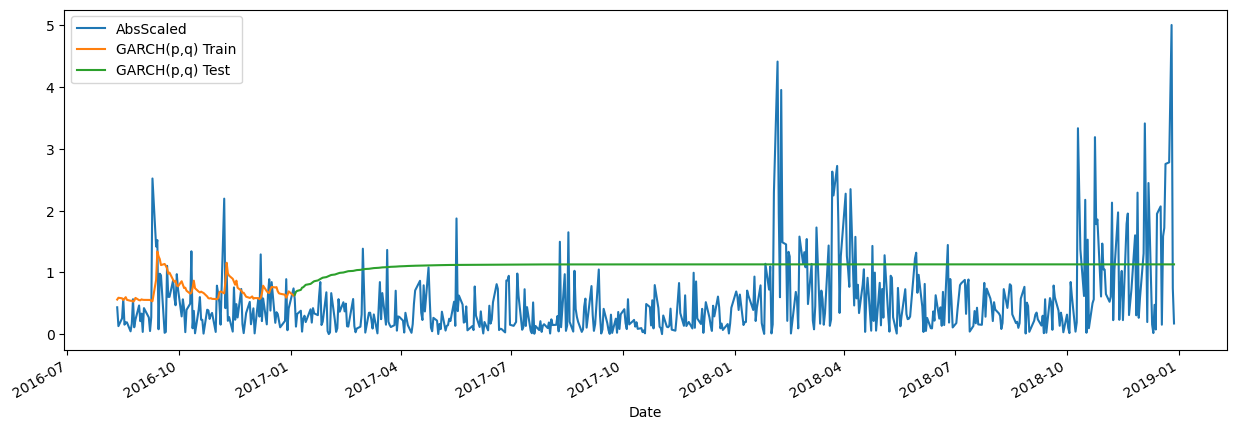

In [153]:
plt_cols = ['AbsScaled', 'GARCH(p,q) Train', 'GARCH(p,q) Test']
df2.iloc[-(Ntest+100):][plt_cols].plot(figsize =(15,5));


In [155]:
'''as expected for the test forecast of the variance  just converges to the unconditional variance'''
''' the actual variance doesnt follow this pattern'''
''' however, predictions seem to be somewhere in the middle below the highest and above the lowest values '''
''' no model can predict random volatility fluctuations several years ahead'''

' no model can predict random volatility fluctuations several years ahead'

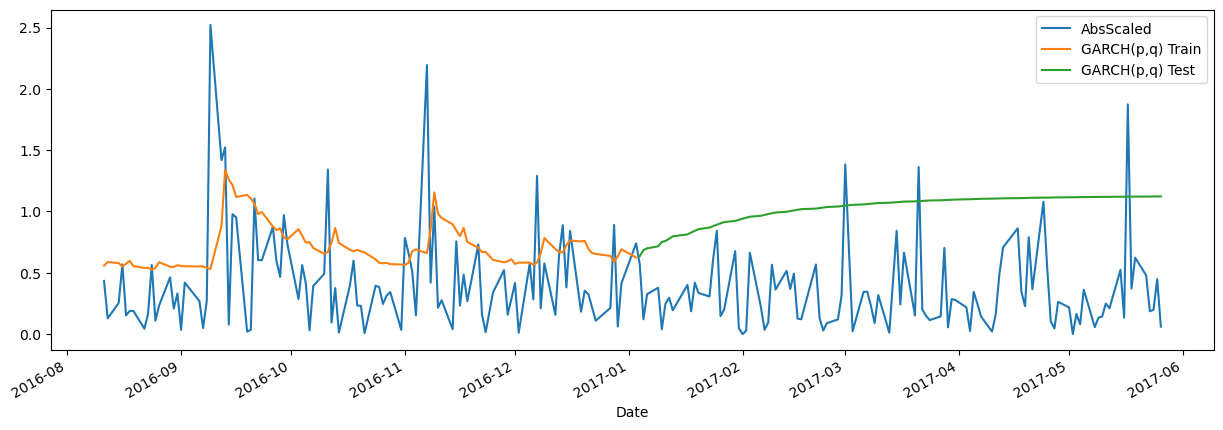

In [154]:
df2.iloc[-(Ntest+100):-(Ntest-100)][plt_cols].plot(figsize =(15,5));

In [156]:
''' even for few time steps ahead, garch is not useful foe test set'''
''' able to predict train set well since it has access to the last actual data which is not the case in test set since its only looking 
at the last data point of train set to make pmultistep prediction'''

' able to predict train set well since it has access to the last actual data which is not the case in test set since its only looking \nat the last data point of train set to make pmultistep prediction'

In [158]:
'''
So, why do we use GARCH if it can't predict the spikes?
    
    - Risk Management (Value at Risk): Banks don't need to know when the spike happens as much as they need to know the range of potential losses. 
    Even if the forecast is a smooth line, that line represents the "expected" baseline of risk.

    -The "One-Step Ahead" Rule: we rarely forecast 100 days into the future without updating the model.
    They predict Day 1, wait for the market to close, feed that new "shock" into the model, and then predict Day 2.
    In a rolling setup, GARCH is very effective.

    - While it can't predict a random spike, GARCH is excellent at predicting that if a spike happens today, 
    volatility will likely remain high tomorrow.

'''

'\nSo, why do we use GARCH if it can\'t predict the spikes?\n    \n    - Risk Management (Value at Risk): Banks don\'t need to know when the spike happens as much as they need to know the range of potential losses. \n    Even if the forecast is a smooth line, that line represents the "expected" baseline of risk.\n\n    -The "One-Step Ahead" Rule: we rarely forecast 100 days into the future without updating the model.\n    They predict Day 1, wait for the market to close, feed that new "shock" into the model, and then predict Day 2.\n    In a rolling setup, GARCH is very effective.\n\n    - While it can\'t predict a random spike, GARCH is excellent at predicting that if a spike happens today, \n    volatility will likely remain high tomorrow.\n\n'